# CSV Editor Notebook

| Cell | Operation |
|------|-----------|
| **1** | Install & Imports |
| **2** | Configuration |
| **3** | All helper functions (run once) |
| **4** | ▶ Step 1 — Add `filename` column to source CSV |
| **5a** | ▶ Step 2a — Generate CSV from **local** image directory |
| **5b** | ▶ Step 2b — Generate CSV from **Wasabi bucket** (S3) |
| **6** | ▶ Step 3 — Compare both CSVs (stats + lists + charts) |

## 1 — Install & Imports

In [1]:
%pip install pandas matplotlib seaborn tqdm boto3 python-dotenv --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import warnings
from pathlib import Path

import boto3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from botocore.config import Config
from botocore.exceptions import ClientError
from tqdm import tqdm

try:
    from dotenv import load_dotenv
    load_dotenv(Path("..") / ".env", override=True)
    print("✓ .env loaded")
except Exception:
    pass

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_rows", 30)

print(f"pandas  {pd.__version__}")
print("✓ imports ready")

✓ .env loaded
pandas  3.0.2
✓ imports ready


## 2 — Configuration

In [3]:
# ── Source CSV ─────────────────────────────────────────────────────────────
SOURCE_CSV = "/home/taiaburrahman/dataset_manager_pro/data/csv/train_fold_5.csv"

# ── Output directory for processed CSVs ────────────────────────────────────
OUTPUT_DIR = Path("/home/taiaburrahman/dataset_manager_pro/data/processed/csv")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Local image directory to scan (Step 2a) ────────────────────────────────
IMAGE_SCAN_DIR = "/home/taiaburrahman/dataset_manager_pro/data/processed/gen_ai_detector_dataset_scaled_224"

# ── Wasabi config (Step 2b) ────────────────────────────────────────────────
# Reads from .env automatically; override here if needed.
WASABI_ACCESS_KEY_ID     = os.getenv("WASABI_ACCESS_KEY_ID",     "")
WASABI_SECRET_ACCESS_KEY = os.getenv("WASABI_SECRET_ACCESS_KEY", "")
WASABI_BUCKET            = os.getenv("WASABI_BUCKET",            "")
WASABI_REGION            = os.getenv("WASABI_REGION",            "us-east-1")
WASABI_ENDPOINT          = os.getenv("WASABI_ENDPOINT",          "https://s3.wasabisys.com")

# S3 prefix to scan in the bucket (Step 2b)
WASABI_SCAN_PREFIX = "datasets/gen_ai_detector_dataset_scaled_224/"

# Label mapping: key-path substring → integer label  (0 = fake, 1 = real)
LABEL_MAP = {
    "genai":                 0,
    "ai_image_x_collection": 0,
    "human":                 1,
}

# File extensions to include (set empty to include everything)
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tiff", ".tif",
              ".tar.lz4", ".tar.gz", ".tar.zst", ".zip"}  # archives count too

print(f"Source CSV      : {SOURCE_CSV}")
print(f"Output dir      : {OUTPUT_DIR}")
print(f"Local scan dir  : {IMAGE_SCAN_DIR}")
print(f"Wasabi bucket   : {WASABI_BUCKET}")
print(f"Wasabi prefix   : {WASABI_SCAN_PREFIX}")

Source CSV      : /home/taiaburrahman/dataset_manager_pro/data/csv/train_fold_5.csv
Output dir      : /home/taiaburrahman/dataset_manager_pro/data/processed/csv
Local scan dir  : /home/taiaburrahman/dataset_manager_pro/data/processed/gen_ai_detector_dataset_scaled_224
Wasabi bucket   : bbvision
Wasabi prefix   : datasets/gen_ai_detector_dataset_scaled_224/


## 3 — Helper Functions

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def _box(lines: list[str], width: int = 72) -> str:
    sep = "─" * (width - 2)
    def row(s): return f"║  {s:<{width-4}}║"
    out = [f"╔{sep}╗"]
    for l in lines:
        out.append(f"╠{sep}╣" if l == "---" else row(l))
    out.append(f"╚{sep}╝")
    return "\n".join(out)


def _infer_label(top_folder: str) -> int | None:
    """Map a top-level subfolder name to a label using LABEL_MAP prefixes."""
    key = top_folder.lower()
    for prefix, label in LABEL_MAP.items():
        if key.startswith(prefix):
            return label
    return None   # unknown


# ── Step 1 ─────────────────────────────────────────────────────────────────

def add_filename_column(
    source_csv:  str | Path,
    output_dir:  str | Path,
    path_col:    str = "image_path",
    output_name: str | None = None,
) -> pd.DataFrame:
    """
    Load *source_csv*, extract the filename from *path_col* (basename),
    add it as a new column 'filename', and save to *output_dir*.

    Returns the modified DataFrame.
    """
    src  = Path(source_csv)
    out  = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)

    print(f"Loading {src.name} …")
    df = pd.read_csv(src, dtype=str, low_memory=False)

    if path_col not in df.columns:
        raise ValueError(f"Column '{path_col}' not found. Available: {list(df.columns)}")

    df["filename"] = df[path_col].apply(lambda p: Path(str(p)).name)

    stem        = output_name or (src.stem + "_with_filename")
    dest        = out / (stem + ".csv")
    df.to_csv(dest, index=False)

    # Preview
    print(df[[path_col, "filename"]].head(5).to_string(index=False))
    print(_box([
        "STEP 1 — ADD FILENAME COLUMN", "---",
        f"Source         : {src.name}",
        f"Saved to       : {dest}",
        "---",
        f"Rows           : {len(df):,}",
        f"Columns        : {list(df.columns)}",
        f"Unique filenames: {df['filename'].nunique():,}",
    ]))
    return df


# ── Step 2 ─────────────────────────────────────────────────────────────────

def scan_image_dir(
    scan_dir:    str | Path,
    output_dir:  str | Path,
    output_name: str = "scanned_images",
) -> pd.DataFrame:
    """
    Walk *scan_dir* recursively, collect all image files, build a DataFrame
    with columns matching the source CSV (image_path, labels, directory,
    filename), and save to *output_dir*.

    Labels are inferred from the top-level subfolder name using LABEL_MAP.
    """
    root = Path(scan_dir)
    out  = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)

    print(f"Scanning {root} …")
    records = []

    top_folders = sorted([d for d in root.iterdir() if d.is_dir()])
    print(f"  Sub-folders : {[d.name for d in top_folders]}\n")

    for top in top_folders:
        label = _infer_label(top.name)
        files = [f for f in top.rglob("*")
                 if f.is_file() and f.suffix.lower() in IMAGE_EXTS]
        for f in tqdm(files, desc=f"  {top.name}", leave=True):
            records.append({
                "image_path": str(f),
                "labels":     label,
                "directory":  top.name,
                "filename":   f.name,
            })

    df   = pd.DataFrame(records)
    dest = out / (output_name + ".csv")
    df.to_csv(dest, index=False)

    label_counts = df["labels"].value_counts().to_dict()
    print(_box([
        "STEP 2 — SCAN IMAGE DIRECTORY", "---",
        f"Scanned        : {root}",
        f"Saved to       : {dest}",
        "---",
        f"Total images   : {len(df):,}",
        f"Label 0 (fake) : {label_counts.get(0, 0):,}",
        f"Label 1 (real) : {label_counts.get(1, 0):,}",
        f"Unknown label  : {label_counts.get(None, 0):,}",
        f"Unique filenames: {df['filename'].nunique():,}",
    ]))
    return df


# ── Step 3 ─────────────────────────────────────────────────────────────────

def compare_csvs(
    df_source:   pd.DataFrame | str | Path,
    df_scanned:  pd.DataFrame | str | Path,
    output_dir:  str | Path,
    compare_col: str = "filename",
) -> dict:
    """
    Compare two DataFrames (or CSV paths) on *compare_col*.

    Returns a dict with:
      common          — filenames in both
      only_in_source  — filenames only in source CSV
      only_in_scanned — filenames only in scanned CSV

    Saves difference lists to CSVs and displays bar + pie charts.
    """
    out = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)

    if isinstance(df_source, (str, Path)):
        print(f"Loading source  CSV …")
        df_source  = pd.read_csv(df_source,  dtype=str, low_memory=False)
    if isinstance(df_scanned, (str, Path)):
        print(f"Loading scanned CSV …")
        df_scanned = pd.read_csv(df_scanned, dtype=str, low_memory=False)

    if compare_col not in df_source.columns:
        df_source  = df_source.copy()
        df_source[compare_col]  = df_source["image_path"].apply(lambda p: Path(str(p)).name)
    if compare_col not in df_scanned.columns:
        df_scanned = df_scanned.copy()
        df_scanned[compare_col] = df_scanned["image_path"].apply(lambda p: Path(str(p)).name)

    set_src = set(df_source[compare_col].dropna())
    set_scn = set(df_scanned[compare_col].dropna())

    common          = set_src & set_scn
    only_in_source  = set_src - set_scn
    only_in_scanned = set_scn - set_src

    # ── Save difference lists ──────────────────────────────────────────────
    def _save_list(names, tag):
        rows = df_source[df_source[compare_col].isin(names)] if "source" in tag \
               else df_scanned[df_scanned[compare_col].isin(names)]
        p = out / f"compare_{tag}.csv"
        rows.to_csv(p, index=False)
        return p

    p_common  = out / "compare_common.csv"
    df_source[df_source[compare_col].isin(common)].to_csv(p_common, index=False)
    p_only_src = _save_list(only_in_source,  "only_in_source")
    p_only_scn = _save_list(only_in_scanned, "only_in_scanned")

    # ── Text summary ──────────────────────────────────────────────────────
    print(_box([
        "STEP 3 — CSV COMPARISON SUMMARY", "---",
        f"Compare column      : '{compare_col}'",
        "---",
        f"Source CSV          : {len(set_src):>10,} unique filenames",
        f"Scanned CSV         : {len(set_scn):>10,} unique filenames",
        "---",
        f"✓  Common (both)    : {len(common):>10,}",
        f"◀  Only in source   : {len(only_in_source):>10,}",
        f"▶  Only in scanned  : {len(only_in_scanned):>10,}",
        "---",
        f"common CSV          : {p_common}",
        f"only_in_source CSV  : {p_only_src}",
        f"only_in_scanned CSV : {p_only_scn}",
    ]))

    # ── Sample lists ──────────────────────────────────────────────────────
    print("\n── Sample: common files (first 10) ──")
    display(df_source[df_source[compare_col].isin(common)][[compare_col, "labels"]].head(10))

    print("\n── Sample: only in SOURCE csv (first 10) ──")
    display(df_source[df_source[compare_col].isin(only_in_source)][[compare_col, "labels"]].head(10))

    print("\n── Sample: only in SCANNED csv (first 10) ──")
    display(df_scanned[df_scanned[compare_col].isin(only_in_scanned)][[compare_col, "labels"]].head(10))

    # ── Charts ────────────────────────────────────────────────────────────
    _plot_comparison(
        len(common), len(only_in_source), len(only_in_scanned),
        len(set_src), len(set_scn),
        df_source, df_scanned, compare_col, common, out,
    )

    return {
        "common":          common,
        "only_in_source":  only_in_source,
        "only_in_scanned": only_in_scanned,
    }


def _plot_comparison(
    n_common, n_only_src, n_only_scn,
    n_src_total, n_scn_total,
    df_source, df_scanned, compare_col,
    common_set, out_dir,
):
    """Render and save 4 charts: bar overview, stacked bar per CSV,
       two donut pies (composition of each CSV)."""
    sns.set_theme(style="whitegrid", palette="muted")
    COLORS = {"common": "#4CAF50", "only_src": "#2196F3", "only_scn": "#FF9800"}

    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    fig.suptitle("CSV Comparison — Filename Overlap Analysis",
                 fontsize=15, fontweight="bold", y=1.01)

    # ── 1. Overview bar chart ─────────────────────────────────────────────
    ax = axes[0, 0]
    categories = ["Common\n(both)", "Only in\nSource CSV", "Only in\nScanned CSV"]
    counts     = [n_common, n_only_src, n_only_scn]
    colors     = [COLORS["common"], COLORS["only_src"], COLORS["only_scn"]]
    bars = ax.bar(categories, counts, color=colors, edgecolor="white", width=0.5)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(counts) * 0.01,
                f"{count:,}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title("Overview: Filename Overlap", fontsize=12, fontweight="bold")
    ax.set_ylabel("Number of Files")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

    # ── 2. Stacked bar per CSV ────────────────────────────────────────────
    ax = axes[0, 1]
    csv_names  = ["Source CSV", "Scanned CSV"]
    n_common_s = [n_common,   n_common]
    n_unique_s = [n_only_src, n_only_scn]
    b1 = ax.bar(csv_names, n_common_s, color=COLORS["common"],  label="Common",        edgecolor="white")
    b2 = ax.bar(csv_names, n_unique_s, bottom=n_common_s,
                color=[COLORS["only_src"], COLORS["only_scn"]], label="Unique to this", edgecolor="white")
    for bar, total in zip(b1, [n_src_total, n_scn_total]):
        ax.text(bar.get_x() + bar.get_width()/2, total + max(n_src_total, n_scn_total) * 0.01,
                f"Total\n{total:,}", ha="center", va="bottom", fontsize=9)
    ax.set_title("Per-CSV Composition", fontsize=12, fontweight="bold")
    ax.set_ylabel("Number of Files")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.legend()

    # ── 3. Source CSV donut ───────────────────────────────────────────────
    ax = axes[1, 0]
    wedge_sizes = [n_common, n_only_src]
    wedge_labels = [f"Common\n{n_common:,}", f"Only in Source\n{n_only_src:,}"]
    wedge_colors = [COLORS["common"], COLORS["only_src"]]
    if sum(wedge_sizes) > 0:
        wedges, texts, autotexts = ax.pie(
            wedge_sizes, labels=wedge_labels, colors=wedge_colors,
            autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(width=0.55, edgecolor="white"),
        )
        for t in autotexts: t.set_fontsize(9)
    ax.set_title(f"Source CSV  ({n_src_total:,} total)", fontsize=12, fontweight="bold")

    # ── 4. Scanned CSV donut ──────────────────────────────────────────────
    ax = axes[1, 1]
    wedge_sizes = [n_common, n_only_scn]
    wedge_labels = [f"Common\n{n_common:,}", f"Only in Scanned\n{n_only_scn:,}"]
    wedge_colors = [COLORS["common"], COLORS["only_scn"]]
    if sum(wedge_sizes) > 0:
        wedges, texts, autotexts = ax.pie(
            wedge_sizes, labels=wedge_labels, colors=wedge_colors,
            autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(width=0.55, edgecolor="white"),
        )
        for t in autotexts: t.set_fontsize(9)
    ax.set_title(f"Scanned CSV  ({n_scn_total:,} total)", fontsize=12, fontweight="bold")

    plt.tight_layout()
    chart_path = out_dir / "compare_charts.png"
    plt.savefig(chart_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\n  Charts saved → {chart_path}")

    # ── 5. Label breakdown bar (common vs unique, per label) ──────────────
    if "labels" in df_source.columns and "labels" in df_scanned.columns:
        fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
        fig2.suptitle("Label Distribution — Common vs Unique",
                      fontsize=13, fontweight="bold")

        for ax2, (df_, title) in zip(axes2,
                [(df_source, "Source CSV"), (df_scanned, "Scanned CSV")]):
            is_common = df_[compare_col].isin(common_set)
            df_["_group"] = is_common.map({True: "Common", False: "Unique"})
            grp = df_.groupby(["_group", "labels"]).size().reset_index(name="count")
            grp["labels"] = grp["labels"].map({"0": "Fake (0)", "1": "Real (1)",
                                                0: "Fake (0)", 1: "Real (1)"}).fillna("Unknown")
            pivot = grp.pivot(index="labels", columns="_group", values="count").fillna(0)
            pivot.plot(kind="bar", ax=ax2, colormap="Set2", edgecolor="white", rot=0)
            ax2.set_title(title, fontsize=11, fontweight="bold")
            ax2.set_xlabel("Label")
            ax2.set_ylabel("Count")
            ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
            ax2.legend(title="Group")
            df_.drop(columns="_group", inplace=True)

        plt.tight_layout()
        chart2_path = out_dir / "compare_label_breakdown.png"
        plt.savefig(chart2_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"  Label breakdown saved → {chart2_path}")


# ── Step 2b: Wasabi bucket scan ────────────────────────────────────────────

def _get_wasabi_client():
    """Build a boto3 S3 client from the config variables."""
    def _g(name, default=""):
        return globals().get(name) or os.getenv(name, default)
    return boto3.client(
        "s3",
        endpoint_url=_g("WASABI_ENDPOINT", "https://s3.wasabisys.com"),
        region_name=_g("WASABI_REGION", "us-east-1"),
        aws_access_key_id=_g("WASABI_ACCESS_KEY_ID"),
        aws_secret_access_key=_g("WASABI_SECRET_ACCESS_KEY"),
        config=Config(signature_version="s3v4",
                      retries={"max_attempts": 3, "mode": "adaptive"}),
    )


def _infer_label_from_key(key: str) -> int | None:
    """Infer label from any part of the S3 key using LABEL_MAP prefixes."""
    key_lower = key.lower()
    for substr, label in LABEL_MAP.items():
        if substr in key_lower:
            return label
    return None


def scan_wasabi_bucket(
    prefix:      str,
    output_dir:  str | Path,
    output_name: str = "wasabi_scanned",
    ext_filter:  set | None = None,
    max_keys:    int | None = None,
) -> pd.DataFrame:
    """
    List all objects under *prefix* in the configured Wasabi bucket,
    build a DataFrame with columns (image_path, labels, directory, filename),
    and save it to *output_dir*.

    Parameters
    ----------
    prefix      : S3 key prefix to scan, e.g. 'datasets/gen_ai_detector_dataset_scaled_224/'
    output_dir  : Local directory to save the output CSV.
    output_name : Output CSV filename stem.
    ext_filter  : Set of lowercase extensions to keep (e.g. {'.jpg', '.png'}).
                  Pass None or empty set to include ALL objects.
    max_keys    : Stop after collecting this many rows (useful for quick tests).
    """
    client = _get_wasabi_client()
    bucket = globals().get("WASABI_BUCKET") or os.getenv("WASABI_BUCKET", "")
    out    = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)

    # Normalise prefix
    if prefix and not prefix.endswith("/"):
        prefix += "/"

    print(f"Scanning Wasabi bucket '{bucket}' — prefix: '{prefix}' …")

    paginator = client.get_paginator("list_objects_v2")
    records   = []
    page_num  = 0

    with tqdm(desc="Listing objects", unit=" obj", dynamic_ncols=True) as bar:
        for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
            page_num += 1
            for obj in page.get("Contents", []):
                key  = obj["Key"]
                name = Path(key).name

                # Skip folder placeholder objects (zero-byte, key ends with /)
                if not name or key.endswith("/"):
                    continue

                # Optional extension filter
                if ext_filter:
                    sfx = "".join(Path(name).suffixes).lower()   # handles .tar.lz4
                    if not any(sfx.endswith(e) for e in ext_filter):
                        continue

                # Infer top-level subdirectory relative to prefix
                rel       = key[len(prefix):]
                top_dir   = rel.split("/")[0] if "/" in rel else ""
                label     = _infer_label_from_key(key)

                records.append({
                    "image_path":    f"s3://{bucket}/{key}",
                    "labels":        label,
                    "directory":     top_dir,
                    "filename":      name,
                    "s3_key":        key,
                    "size_bytes":    obj["Size"],
                    "last_modified": obj["LastModified"].isoformat(),
                })
                bar.update(1)

                if max_keys and len(records) >= max_keys:
                    break
            if max_keys and len(records) >= max_keys:
                break

    df   = pd.DataFrame(records)
    dest = out / (output_name + ".csv")
    df.to_csv(dest, index=False)

    label_counts = df["labels"].value_counts(dropna=False).to_dict()
    total_size   = df["size_bytes"].sum() if "size_bytes" in df.columns else 0
    tsize_str    = f"{total_size/1024**3:.2f} GB" if total_size > 1024**3 else \
                   f"{total_size/1024**2:.1f} MB"

    print(_box([
        "STEP 2b — SCAN WASABI BUCKET", "---",
        f"Bucket         : {bucket}",
        f"Prefix         : {prefix}",
        f"Saved to       : {dest}",
        "---",
        f"Total objects  : {len(df):,}",
        f"Total size     : {tsize_str}",
        f"Label 0 (fake) : {label_counts.get(0, 0):,}",
        f"Label 1 (real) : {label_counts.get(1, 0):,}",
        f"Unknown label  : {label_counts.get(None, 0):,}",
        f"Unique filenames: {df['filename'].nunique():,}",
    ]))
    return df


print("✓ All helpers loaded")

✓ All helpers loaded


## 4 — Step 1: Add `filename` Column to Source CSV

Extracts `Path(image_path).name` from every row and saves the enriched CSV.

In [5]:
df_source = add_filename_column(
    source_csv  = SOURCE_CSV,
    output_dir  = OUTPUT_DIR,
    output_name = "train_fold_5_with_filename",   # ← output file stem
)

Loading train_fold_5.csv …


                                                                                           image_path                             filename
/home/ubuntu/vision/data/NewDB/NewDB_Real/Shutterstock_Real/real/0e35d3c709ef4123bb7b8cff23c885a4.jpg 0e35d3c709ef4123bb7b8cff23c885a4.jpg
                         /home/ubuntu/vision/data/NewDB/NewDB_Real/tristanzhang32_Real/real/12905.jpg                            12905.jpg
                              /home/ubuntu/vision/data/NewDB/NewDB_Fake/pixelpulse_1800/fake/1085.jpg                             1085.jpg
                               /home/ubuntu/vision/data/NewDB/NewDB_Real/ulid25k/real/image_05650.png                      image_05650.png
/home/ubuntu/vision/data/NewDB/NewDB_Fake/Shutterstock_Fake/fake/d3c613a6d9574f55b3854643c5ca2374.jpg d3c613a6d9574f55b3854643c5ca2374.jpg
╔──────────────────────────────────────────────────────────────────────╗
║  STEP 1 — ADD FILENAME COLUMN                                        ║
╠───────────────────

## 5 — Step 2: Generate CSV from Scanned Image Directory

Walks every subfolder in `IMAGE_SCAN_DIR`, collects all image files, infers labels from the top-level folder name, and writes a CSV with the same schema as the source.

In [6]:
df_scanned = scan_image_dir(
    scan_dir    = IMAGE_SCAN_DIR,
    output_dir  = OUTPUT_DIR,
    output_name = "gen_ai_detector_scanned",   # ← output file stem
)

Scanning /home/taiaburrahman/dataset_manager_pro/data/processed/gen_ai_detector_dataset_scaled_224 …
  Sub-folders : ['ai_image_x_collection_feb25_cleaned', 'genAI', 'genAI_2', 'genAI_3', 'genAI_4', 'genAI_5', 'genAI_6', 'human', 'human_2', 'human_3']



  human_3: 100%|██████████| 1274/1274 [00:00<00:00, 931580.07it/s]


╔──────────────────────────────────────────────────────────────────────╗
║  STEP 2 — SCAN IMAGE DIRECTORY                                       ║
╠──────────────────────────────────────────────────────────────────────╣
║  Scanned        : /home/taiaburrahman/dataset_manager_pro/data/processed/gen_ai_detector_dataset_scaled_224║
║  Saved to       : /home/taiaburrahman/dataset_manager_pro/data/processed/csv/gen_ai_detector_scanned.csv║
╠──────────────────────────────────────────────────────────────────────╣
║  Total images   : 705,294                                            ║
║  Label 0 (fake) : 349,181                                            ║
║  Label 1 (real) : 356,113                                            ║
║  Unknown label  : 0                                                  ║
║  Unique filenames: 703,495                                           ║
╚──────────────────────────────────────────────────────────────────────╝


## Step 2b — Generate CSV from Wasabi Bucket

Lists objects directly from the S3 bucket. Set `WASABI_SCAN_PREFIX` in Configuration, then run this cell.  
Use `EXT_FILTER` to restrict to image extensions, or leave it `None` to include all objects (archives, parquet, etc.).

In [7]:
# ── INPUT ──────────────────────────────────────────────────────────────────
WASABI_PREFIX  = WASABI_SCAN_PREFIX   # e.g. "datasets/gen_ai_detector_dataset_scaled_224/"
OUTPUT_NAME    = "wasabi_scanned"     # output CSV filename stem

# Extension filter — set to None to include ALL objects in the prefix
# Examples:
#   None                              → everything
#   {".jpg", ".jpeg", ".png"}        → images only
#   {".tar.lz4", ".tar.gz", ".zip"}  → archives only
EXT_FILTER = None

# Set MAX_KEYS to a small number for a quick preview, None for the full scan
MAX_KEYS = None   # e.g. 50 for a test run
# ───────────────────────────────────────────────────────────────────────────

df_scanned = scan_wasabi_bucket(
    prefix      = WASABI_PREFIX,
    output_dir  = OUTPUT_DIR,
    output_name = OUTPUT_NAME,
    ext_filter  = EXT_FILTER,
    max_keys    = MAX_KEYS,
)

# Preview
display(df_scanned[["s3_key", "filename", "labels", "directory", "size_bytes"]].head(10))

Scanning Wasabi bucket 'bbvision' — prefix: 'datasets/gen_ai_detector_dataset_scaled_224/' …


Listing objects: 10 obj [00:00, 38.29 obj/s]

╔──────────────────────────────────────────────────────────────────────╗
║  STEP 2b — SCAN WASABI BUCKET                                        ║
╠──────────────────────────────────────────────────────────────────────╣
║  Bucket         : bbvision                                           ║
║  Prefix         : datasets/gen_ai_detector_dataset_scaled_224/       ║
║  Saved to       : /home/taiaburrahman/dataset_manager_pro/data/processed/csv/wasabi_scanned.csv║
╠──────────────────────────────────────────────────────────────────────╣
║  Total objects  : 10                                                 ║
║  Total size     : 43.92 GB                                           ║
║  Label 0 (fake) : 7                                                  ║
║  Label 1 (real) : 3                                                  ║
║  Unknown label  : 0                                                  ║
║  Unique filenames: 10                                                ║
╚────────────────────────

,s3_key,filename,labels,directory,size_bytes
0,datasets/gen_ai_detector_dataset_scaled_224/ai_image_x_collection_feb25_clea...,ai_image_x_collection_feb25_cleaned.tar.lz4,0,,5543928164
1,datasets/gen_ai_detector_dataset_scaled_224/genAI.tar.lz4,genAI.tar.lz4,0,,13141071174
2,datasets/gen_ai_detector_dataset_scaled_224/genAI_2.tar.lz4,genAI_2.tar.lz4,0,,7734983502
3,datasets/gen_ai_detector_dataset_scaled_224/genAI_3.tar.lz4,genAI_3.tar.lz4,0,,266129540
4,datasets/gen_ai_detector_dataset_scaled_224/genAI_4.tar.lz4,genAI_4.tar.lz4,0,,58048353
5,datasets/gen_ai_detector_dataset_scaled_224/genAI_5.tar.lz4,genAI_5.tar.lz4,0,,5352175
6,datasets/gen_ai_detector_dataset_scaled_224/genAI_6.tar.lz4,genAI_6.tar.lz4,0,,36951566
7,datasets/gen_ai_detector_dataset_scaled_224/human.tar.lz4,human.tar.lz4,1,,19151169968
8,datasets/gen_ai_detector_dataset_scaled_224/human_2.tar.lz4,human_2.tar.lz4,1,,1134504879
9,datasets/gen_ai_detector_dataset_scaled_224/human_3.tar.lz4,human_3.tar.lz4,1,,83275116


## 6 — Step 3: Compare Both CSVs

Compares on the `filename` column (basename). Outputs:
- `compare_common.csv` — files present in **both**
- `compare_only_in_source.csv` — files **only** in source CSV
- `compare_only_in_scanned.csv` — files **only** in scanned CSV
- 4-panel chart + label breakdown chart

╔──────────────────────────────────────────────────────────────────────╗
║  STEP 3 — CSV COMPARISON SUMMARY                                     ║
╠──────────────────────────────────────────────────────────────────────╣
║  Compare column      : 'filename'                                    ║
╠──────────────────────────────────────────────────────────────────────╣
║  Source CSV          :    612,225 unique filenames                   ║
║  Scanned CSV         :         10 unique filenames                   ║
╠──────────────────────────────────────────────────────────────────────╣
║  ✓  Common (both)    :          0                                    ║
║  ◀  Only in source   :    612,225                                    ║
║  ▶  Only in scanned  :         10                                    ║
╠──────────────────────────────────────────────────────────────────────╣
║  common CSV          : /home/taiaburrahman/dataset_manager_pro/data/processed/csv/compare_common.csv║
║  only_in_source CS

,filename,labels



── Sample: only in SOURCE csv (first 10) ──


,filename,labels
0,0e35d3c709ef4123bb7b8cff23c885a4.jpg,1
1,12905.jpg,1
2,1085.jpg,0
3,image_05650.png,1
4,d3c613a6d9574f55b3854643c5ca2374.jpg,0
5,2839.jpg,0
6,5a3fcafb-5fe4-4781-8e76-16df69bc572d.jpg,0
7,image - 2025-03-18T102548.813.jpg,0
8,de2d9174de90417d9c7973a890ef7466.jpg,1
9,4a0bd30a-24d4-4d7c-9594-28c97d7a55ac.jpg,0



── Sample: only in SCANNED csv (first 10) ──


,filename,labels
0,ai_image_x_collection_feb25_cleaned.tar.lz4,0
1,genAI.tar.lz4,0
2,genAI_2.tar.lz4,0
3,genAI_3.tar.lz4,0
4,genAI_4.tar.lz4,0
5,genAI_5.tar.lz4,0
6,genAI_6.tar.lz4,0
7,human.tar.lz4,1
8,human_2.tar.lz4,1
9,human_3.tar.lz4,1


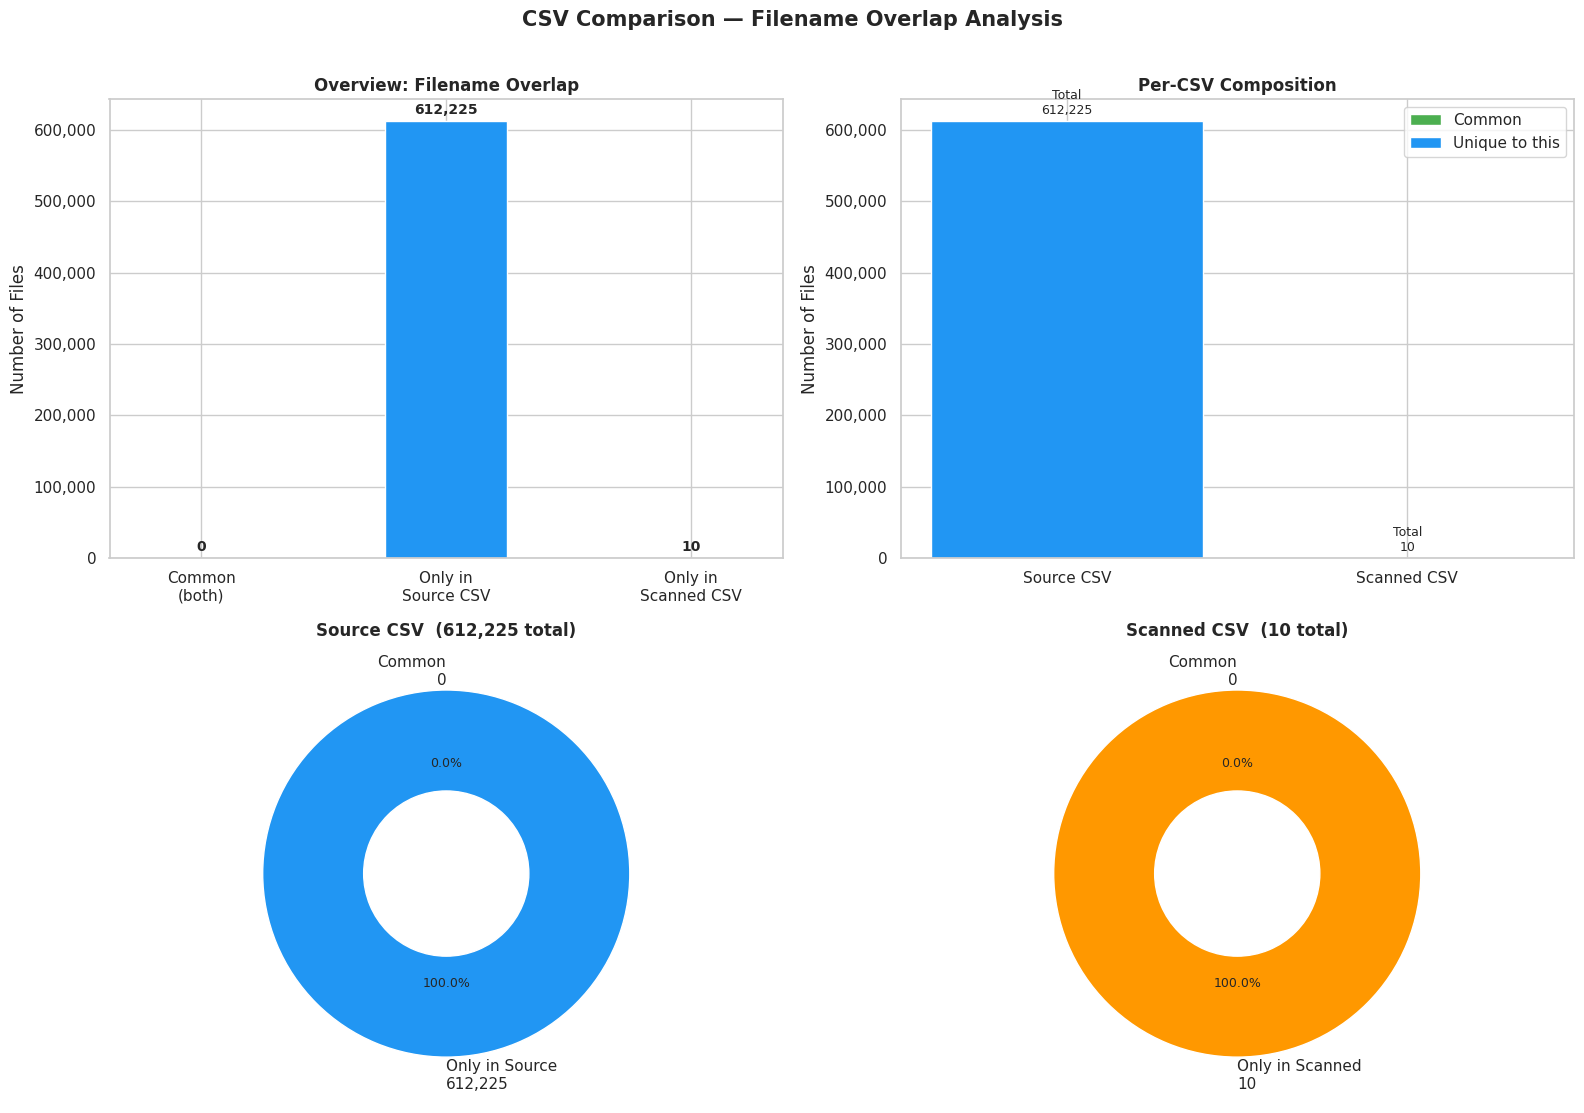


  Charts saved → /home/taiaburrahman/dataset_manager_pro/data/processed/csv/compare_charts.png


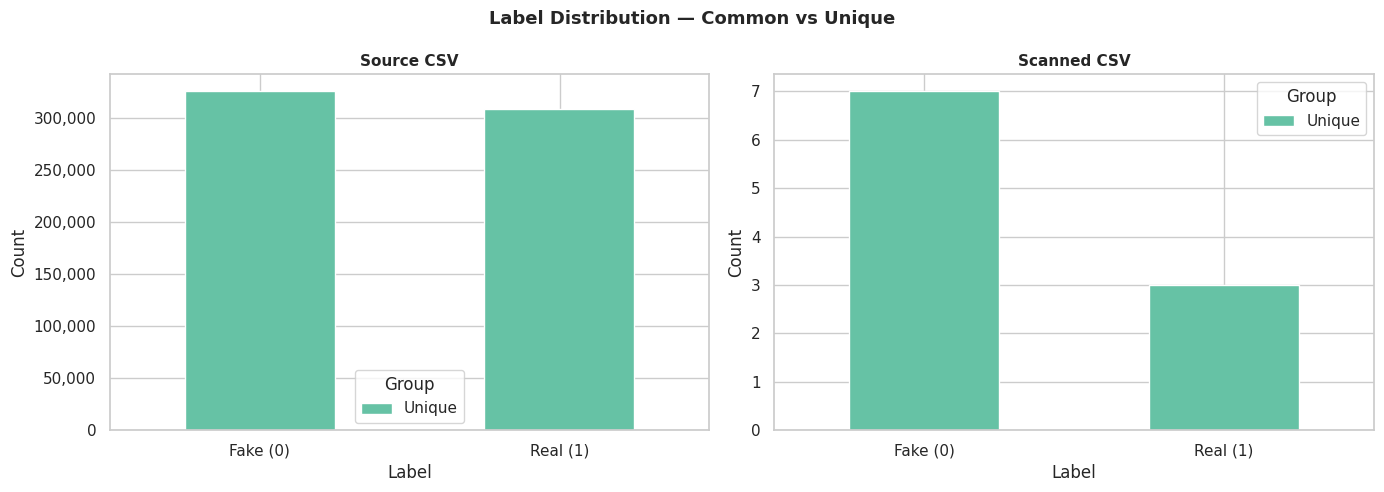

  Label breakdown saved → /home/taiaburrahman/dataset_manager_pro/data/processed/csv/compare_label_breakdown.png


In [8]:
results = compare_csvs(
    df_source  = df_source,    # DataFrame from Step 1 (or pass a CSV path)
    df_scanned = df_scanned,   # DataFrame from Step 2 (or pass a CSV path)
    output_dir = OUTPUT_DIR,
    compare_col = "filename",
)

# results["common"]          → set of filenames in both
# results["only_in_source"]  → set of filenames only in source CSV
# results["only_in_scanned"] → set of filenames only in scanned CSV

## Appendix — Re-run Comparison from Saved CSVs

If you've already run Steps 1 & 2 in a previous session, load the saved CSVs directly:

Loading source  CSV …
Loading scanned CSV …
╔──────────────────────────────────────────────────────────────────────╗
║  STEP 3 — CSV COMPARISON SUMMARY                                     ║
╠──────────────────────────────────────────────────────────────────────╣
║  Compare column      : 'filename'                                    ║
╠──────────────────────────────────────────────────────────────────────╣
║  Source CSV          :    612,225 unique filenames                   ║
║  Scanned CSV         :    703,495 unique filenames                   ║
╠──────────────────────────────────────────────────────────────────────╣
║  ✓  Common (both)    :    469,716                                    ║
║  ◀  Only in source   :    142,509                                    ║
║  ▶  Only in scanned  :    233,779                                    ║
╠──────────────────────────────────────────────────────────────────────╣
║  common CSV          : /home/taiaburrahman/dataset_manager_pro/data/processed/

,filename,labels
6,5a3fcafb-5fe4-4781-8e76-16df69bc572d.jpg,0
9,4a0bd30a-24d4-4d7c-9594-28c97d7a55ac.jpg,0
15,df70f4a5-872e-472d-96d4-51c91908be04.jpg,0
25,143a4227-4133-4954-9413-e25863d3edff.jpg,0
27,ae8b3c84-e676-4dc0-a189-c5ad32374569.jpg,0
45,2cecdead-f701-4b05-a29f-ff5e4ea1483a.jpg,0
52,c4abb0e9-cda7-4d2c-81f1-f1e4d4826894.jpg,0
74,51f5aa72-6e7c-4f4d-90b2-38dd3ca7675b.jpg,0
77,4f2dd794-ca46-4848-bb5f-6b0de90c47bd.jpg,0
101,1bf3c682-c0cc-4506-b2e7-cadd181c3f17.jpg,0



── Sample: only in SOURCE csv (first 10) ──


,filename,labels
0,0e35d3c709ef4123bb7b8cff23c885a4.jpg,1
1,12905.jpg,1
2,1085.jpg,0
3,image_05650.png,1
4,d3c613a6d9574f55b3854643c5ca2374.jpg,0
5,2839.jpg,0
7,image - 2025-03-18T102548.813.jpg,0
8,de2d9174de90417d9c7973a890ef7466.jpg,1
10,0f84b73bab7642a5aa5ea38c47173bcd.jpg,0
11,d97e0ab41f7c4cb895d24322e83314de.jpg,0



── Sample: only in SCANNED csv (first 10) ──


,filename,labels
4,GiMIW_qb0AA92Zs.jpg,0
12,GeIR4OIXcAQKYgJ.jpg,0
21,GdYUDFsaUAA9-Jv.jpg,0
22,GhhyztAWMAAMvqW.jpg,0
27,GcBMoSHagAA3Mi-.jpg,0
33,Gi9aDf9a4AEwMm6.jpg,0
34,GcUv6vobkAAbcbK.jpg,0
41,GeF5zgJakAIMLeW.jpg,0
56,GdQjjpkaoAArIFc.jpg,0
61,GbzdZ3xbIAAJkR9.jpg,0


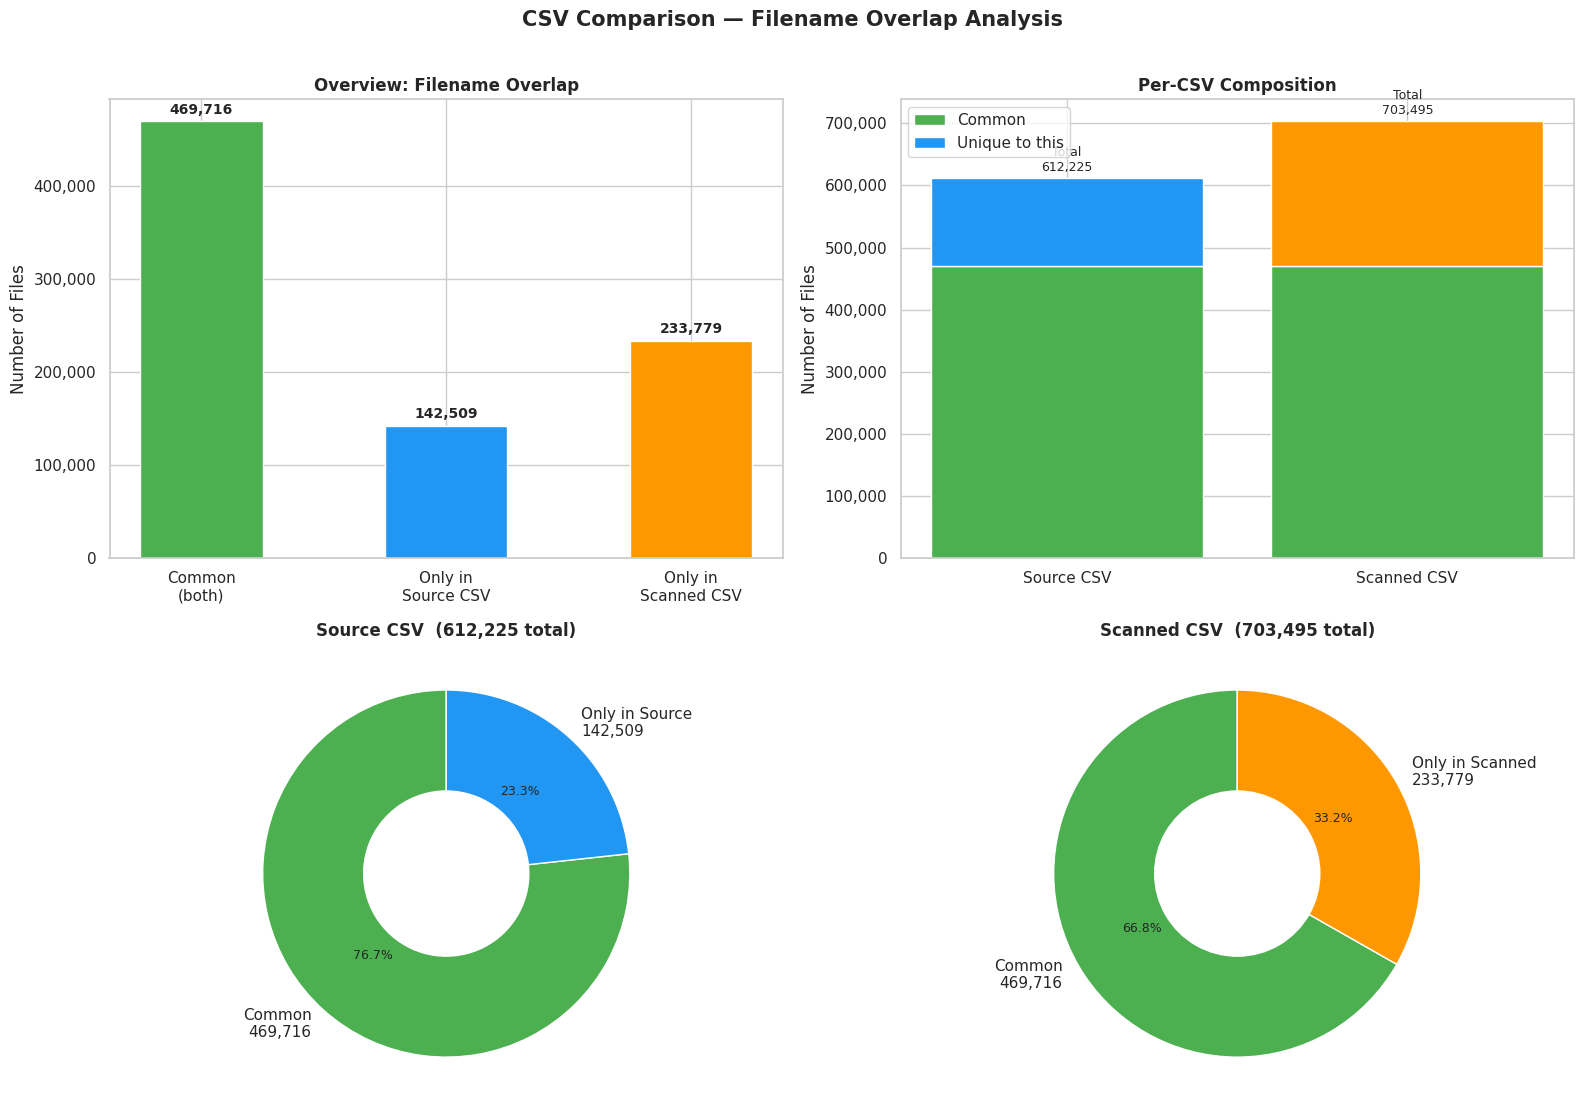


  Charts saved → /home/taiaburrahman/dataset_manager_pro/data/processed/csv/compare_charts.png


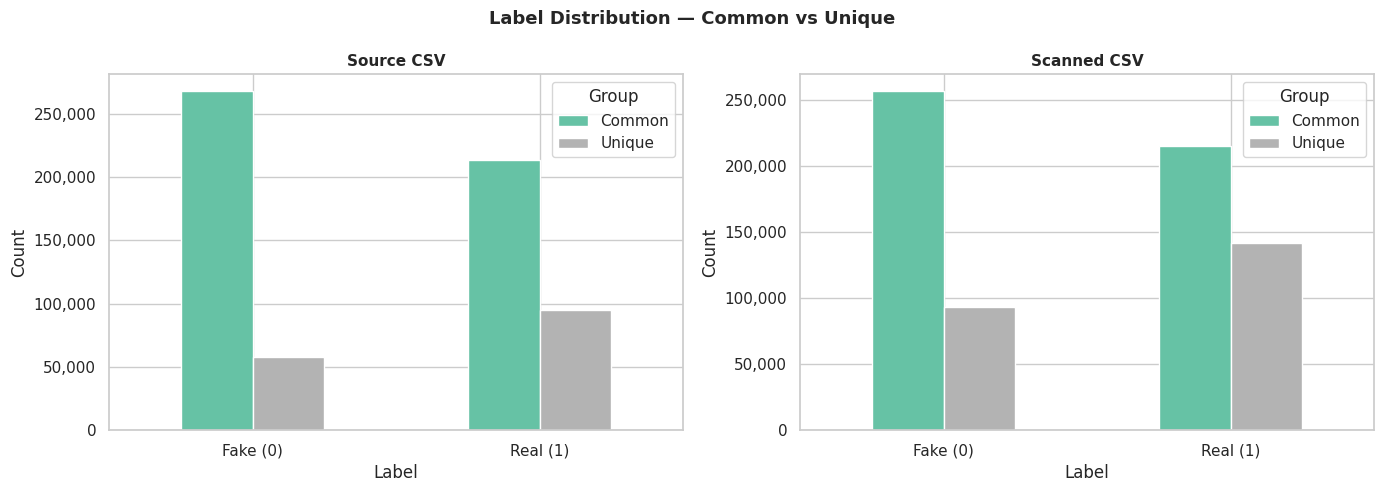

  Label breakdown saved → /home/taiaburrahman/dataset_manager_pro/data/processed/csv/compare_label_breakdown.png


In [9]:
# ── INPUT ─────────────────────────────────────────────────────────────────
CSV_A = OUTPUT_DIR / "train_fold_5_with_filename.csv"
CSV_B = OUTPUT_DIR / "gen_ai_detector_scanned.csv"
# ─────────────────────────────────────────────────────────────────────────

results = compare_csvs(
    df_source  = CSV_A,
    df_scanned = CSV_B,
    output_dir = OUTPUT_DIR,
)